<a href="https://colab.research.google.com/github/briskicedteaa/Scientific-Visualization-for-Computational-Biology/blob/main/UMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv('/content/Ligands2.csv', sep =';' )
df = df.drop(columns=df.columns.difference(['Ligand Efficiency LE', 'Ligand Efficiency LLE', 'Ligand Efficiency BEI', 'Ligand Efficiency SEI', 'Molecular Weight', 'Standard Value', 'AlogP']))
df = df.dropna()
df

,Molecular Weight,AlogP,Standard Value,Ligand Efficiency BEI,Ligand Efficiency LE,Ligand Efficiency LLE,Ligand Efficiency SEI
0,472.67,4.21,60.00,15.28,0.29,3.01,12.61
8,323.39,3.29,657.00,19.12,0.35,2.89,15.95
9,413.52,5.25,22300.00,11.25,0.20,-0.60,12.00
10,379.50,4.36,7.00,21.49,0.40,3.79,21.03
13,427.55,3.69,280.00,15.33,0.28,2.86,6.84
...,...,...,...,...,...,...,...
20124,351.35,3.88,1670.00,16.44,0.33,1.90,12.09
20125,433.49,7.26,7.10,18.80,0.36,0.89,22.05
20126,471.59,8.33,70.00,15.17,0.30,-1.18,19.36
20128,539.81,7.45,7.63,15.04,0.30,0.67,20.94


In [5]:
import umap
reducer = umap.UMAP()

data = df

data.values
scaled_df_data = StandardScaler().fit_transform(data)

In [6]:
embedding = reducer.fit_transform(data)
embedding.shape

(7999, 2)

,Molecular Weight,AlogP,Standard Value,Ligand Efficiency BEI,Ligand Efficiency LE,Ligand Efficiency LLE,Ligand Efficiency SEI,UMAP1,UMAP2
0,472.67,4.21,60.0,15.28,0.29,3.01,12.61,-0.708079,-3.087157
8,323.39,3.29,657.0,19.12,0.35,2.89,15.95,-10.394023,7.011487
9,413.52,5.25,22300.0,11.25,0.20,-0.60,12.00,14.848482,11.794618
10,379.50,4.36,7.0,21.49,0.40,3.79,21.03,-4.842499,-13.228621
13,427.55,3.69,280.0,15.33,0.28,2.86,6.84,-2.926805,2.683068


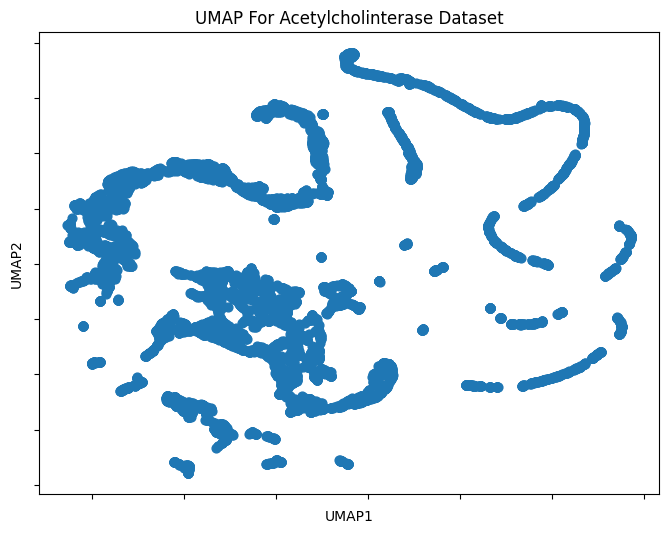

In [11]:
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111)

n_components=2
random_state =42

scatter = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=40,
)

ax.set(
    title="UMAP For Acetylcholinterase Dataset",
    xlabel="UMAP1",
    ylabel="UMAP2"
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

UMAP1 = embedding[:, 0]
UMAP2 = embedding[:, 1]

df['UMAP1'] = UMAP1
df['UMAP2'] = UMAP2

df.to_csv('Ligands2_with_UMAP.csv', index=False)

display(df.head())
plt.show()